# Graph 2

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [5]:
class AgentState(TypedDict):
    value: List[int]
    operation: str
    name: str
    result:str

In [6]:
def process_values(state:AgentState) -> AgentState:
    """This function mulitple different inputs"""
    if state["operation"] == "+":
        answer = sum(state["value"])
    elif state["operation"] == "*":
        answer =1
        for i in state["value"]:
            answer *= i
    state["result"] = f"Hi there {state["name"]}, your answer is {answer}"
    print(state)
    return state

In [7]:
graph = StateGraph(AgentState)

graph.add_node("processer", process_values)
graph.set_entry_point("processer")
graph.set_finish_point("processer")

app = graph.compile()

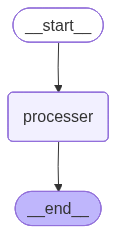

In [8]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
answers = app.invoke({"value":[1,2,3,4], "name": "Jack", "operation":"*"})

{'value': [1, 2, 3, 4], 'operation': '*', 'name': 'Jack', 'result': 'Hi there Jack, your answer is 24'}


In [10]:
print(answers["result"])

Hi there Jack, your answer is 24
